# Verificación — Spark lee tu datalake

**Curso:** ST1630-2026-2 · **Semana:** S4-S5
**Estudiante:** Daniel Arcila Salazar
**Fecha:** 13-08-2026

## Objetivo

Cerrar el Lab 1a confirmando que tu clúster EMR puede leer el datalake
que construiste (Partes 1-4): conectar Spark a tu bucket S3, leer el
archivo Parquet de Bronze, y repetir el benchmark Parquet vs. CSV visto
en la clase de S4.

**Qué debe verse al final para confirmar que el lab está completo:**
- La Celda 2 muestra el schema y 5 filas del Parquet leído desde S3
  (si esto funciona, tu bucket, tu rol IAM y tu clúster están bien
  configurados de punta a punta).
- La Celda 3 imprime el tiempo de una misma consulta en Parquet y en
  CSV, y el ratio entre ambos.
- Completaste el análisis de la Celda 4 y capturaste el DAG de Spark UI
  como indica la Celda 5.

In [8]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# getOrCreate() funciona tanto en EMR (donde ya existe una sesión activa
# administrada por el clúster) como en un entorno local con pyspark
# instalado, sin necesitar ramas de código distintas.
spark = SparkSession.builder.appName("ST1630-Lab1a-Verificacion").getOrCreate()

# EDITAR: reemplaza por el bucket que creaste en setup_s3.sh
# (convención: st1630-{tu-usuario}-{año})
BUCKET = "st1630-darcilas1b-2026"

# En EMR, S3 se referencia directamente con el esquema s3://.
# En local (con las credenciales de AWS Academy exportadas), la misma
# ruta también funciona porque Spark usa el conector S3A por debajo.
ruta_parquet = f"s3://{BUCKET}/bronze/ventas/prueba_parquet.parquet"
ruta_csv = f"s3://{BUCKET}/bronze/ventas/prueba_csv.csv"

df_parquet = spark.read.parquet(ruta_parquet)

df_parquet.printSchema()
df_parquet.show(5, truncate=False)

# Si ves el schema y las filas de arriba, tu datalake funciona
# correctamente de punta a punta: bucket, permisos IAM y clúster EMR.
print("Filas leídas:", df_parquet.count())

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

root
 |-- order_id: string (nullable = true)
 |-- fecha: string (nullable = true)
 |-- region: string (nullable = true)
 |-- producto: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- cantidad: long (nullable = true)
 |-- precio_unit: double (nullable = true)
 |-- total: double (nullable = true)
 |-- canal: string (nullable = true)
 |-- devuelto: boolean (nullable = true)

+----------+----------+------------+---------+-----------+--------+-----------+---------+------+--------+
|order_id  |fecha     |region      |producto |categoria  |cantidad|precio_unit|total    |canal |devuelto|
+----------+----------+------------+---------+-----------+--------+-----------+---------+------+--------+
|ORD-000001|2026-04-22|Cali        |Mouse    |Electrónica|1       |789300.0   |789300.0 |online|false   |
|ORD-000002|2026-03-22|Barranquilla|Gorra    |Ropa       |2       |57000.0    |114000.0 |tienda|false   |
|ORD-000003|2026-01-06|Bogotá      |Zapatos  |Ropa       |4       |16380

In [10]:
import time

df_csv = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(ruta_csv)
)

# Verificación rápida: confirmar que la combinación sí existe
coincidencias = df_parquet.filter(
    (F.col("region") == "Cali") &
    (F.col("categoria") == "Ropa")
).count()

print("Coincidencias Cali + Ropa:", coincidencias)


def benchmark(df, nombre):
    inicio = time.time()

    resultado = (
        df.filter(
            (F.col("region") == "Cali") &
            (F.col("categoria") == "Ropa")
        )
        .groupBy("producto")
        .agg(F.sum("total").alias("total_vendido"))
        .orderBy(F.col("total_vendido").desc())
        .collect()
    )

    duracion = time.time() - inicio

    print(
        f"{nombre}: {duracion:.3f} s "
        f"({len(resultado)} filas de resultado)"
    )

    return duracion


tiempo_parquet = benchmark(df_parquet, "Parquet")
tiempo_csv = benchmark(df_csv, "CSV")

ratio = (
    tiempo_csv / tiempo_parquet
    if tiempo_parquet > 0
    else float("inf")
)

print(f"\nRatio CSV / Parquet: {ratio:.2f}x")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Coincidencias Cali + Ropa: 293
Parquet: 1.474 s (5 filas de resultado)
CSV: 0.923 s (5 filas de resultado)

Ratio CSV / Parquet: 0.63x

## Análisis — completa antes de entregar

### a) Tamaño en disco

¿Cuánto pesa `prueba_parquet.parquet` frente a `prueba_csv.csv`? (revisa
la salida de `generar_datos.py`, o `aws s3 ls --human-readable` sobre
`bronze/ventas/`).

→ Parquet pesa 185.5 KiB y CSV 798.3 KiB.
CSV ocupa aproximadamente 4.3 veces más espacio que Parquet.

### b) Tiempo de la consulta

¿Cuánto tardó la consulta de la Celda 3 en cada formato?

→ Parquet: 1.474 s
CSV: 0.923 s

### c) Ratio de mejora

¿Cuál fue el ratio de mejora (CSV / Parquet) que obtuviste en la Celda 3?
¿Coincide con el orden de magnitud visto en clase (~9x)? Si es distinto,
¿a qué le atribuyes la diferencia (tamaño del clúster, tamaño del
dataset, tipo de consulta)?

→ El ratio fue 0.63x.

No coincide con el ~9x visto en clase. En esta ejecución, CSV fue más rápido que Parquet. Esto puede deberse a que el dataset es muy pequeño para un clúster Spark distribuido, por lo que el overhead de Spark influye bastante en el tiempo total. Además, con solo 10.000 registros, las ventajas de Parquet no se aprovechan completamente.

### d) Conexión con el Teorema CAP

¿Por qué S3 con replicación entre múltiples zonas de disponibilidad es
una decisión **CP** dentro del Teorema CAP? ¿Qué está sacrificando S3 a
cambio de esa garantía de consistencia?

→ S3 se puede relacionar con CP porque prioriza la consistencia y la tolerancia a particiones. Durante una falla de red, puede sacrificar temporalmente la disponibilidad para evitar entregar datos inconsistentes.

## Captura del DAG en Spark UI

1. En EMR Studio (o en la consola de tu clúster), abre **Spark UI /
   History Server**.
2. Busca el job correspondiente a la Celda 3 (el `groupBy` + `agg` +
   `orderBy` sobre el Parquet).
3. Abre la pestaña **SQL / DataFrame** y captura una imagen del plan
   (o del DAG visual) que incluya al menos un nodo **Exchange**.
4. Guarda la captura como `dag_spark_ui.png` dentro de tu carpeta de
   entrega y referencíala en tu PR.

**Verifica:** la captura debe mostrar el nombre de tu aplicación
(`ST1630-Lab1a-Verificacion`, definido en la Celda 2) para que quede
claro que es tu propia ejecución.
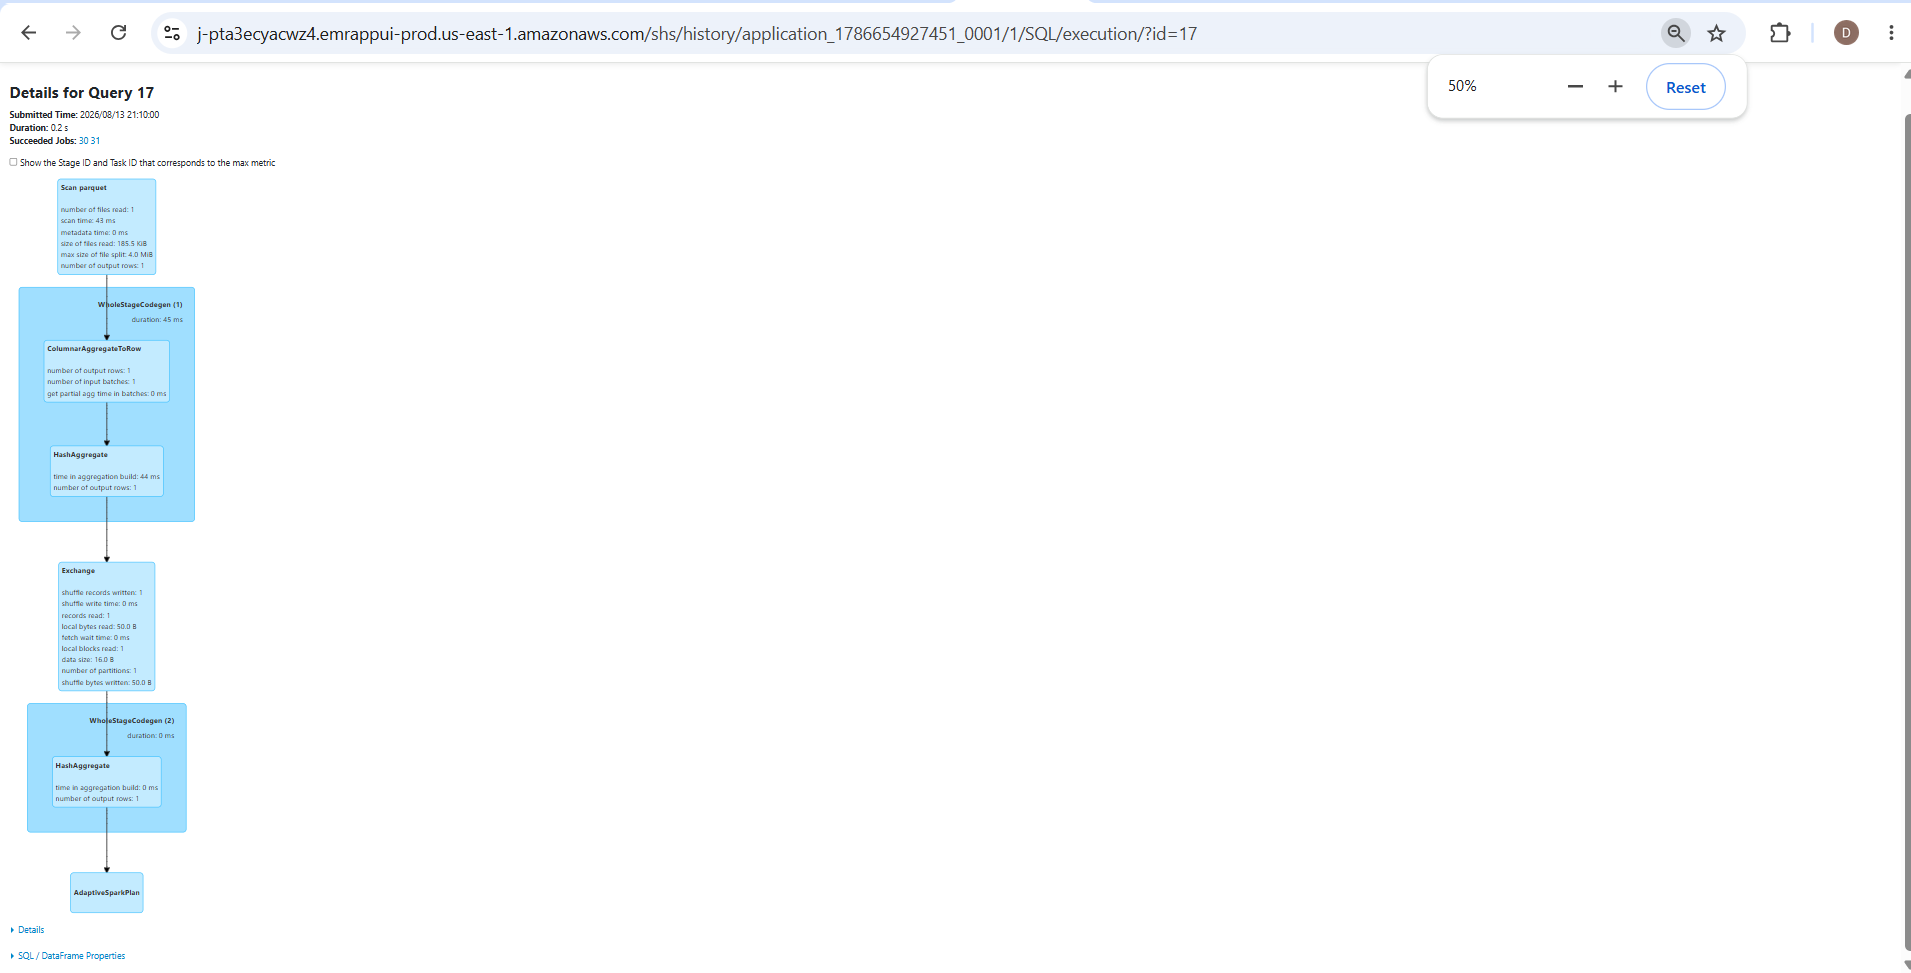

## Bitácora de delegación

Completa según lo que realmente delegaste a un agente de IA durante
este notebook (ver `../../../docs/politica-ia.md`).

| Tarea | ¿Delegado a agente? | Herramienta | Justificación |
|---|---|---|---|
| Boilerplate de SparkSession / lectura de S3 | → No | → — | → El código ya venía incluido en el notebook del laboratorio; únicamente se configuró el bucket correspondiente. |
| Diseño de la consulta del benchmark (Celda 3) | → No | → — | → La consulta filter + groupBy + agg + orderBy ya estaba definida en el notebook del laboratorio. |
| Interpretación de los resultados (Celda 4) | → Parcial | → Codex | → Se utilizó IA como apoyo para entender y organizar los resultados obtenidos, pero las respuestas se basaron en los valores reales de la ejecución. |
| Troubleshooting de errores de conexión a S3 | → Sí | → codex | → Se utilizó IA para identificar y solucionar problemas de configuración de AWS CLI, IAM, EMR, roles, EMR Studio y conexión del clúster, más que todo porque se utilió el sandbox en vez del learner lab |

> Recuerda: la interpretación de los resultados y la conexión con CAP
> (pregunta d) deben reflejar tu propio razonamiento — ver
> `../README.md`, sección "Bitácora de delegación".